# Khối nhận diện danh tính — hai phương án đặt cạnh nhau

Notebook này mở khối nhận diện (KHỐI 1d) ra cho xem: một ảnh khuôn mặt đi vào, một vectơ đặc trưng
đi ra, và hai vectơ so với nhau cho một con số duy nhất quyết định *cùng người* hay *khác người*.

Hai phương án được so sánh trong đề tài:

| | Phương án A | Phương án B |
|---|---|---|
| Mô hình | dlib ResNet | MobileFaceNet (ArcFace) |
| Số chiều vectơ | 128 | 512 |
| Thư viện chạy | `dlib-bin` | ONNX Runtime |
| Mã việc | `P3-02` | `P3-01` |

## Notebook này KHÔNG làm gì

- **Không đo thời gian.** Máy phát triển không phải phần cứng đích, và Jupyter thêm chi phí làm
  sai lệch phép đo. Số hiệu năng đến từ `scripts/benchmark_*.py` chạy trên Raspberry Pi 5.
- **Không chốt ngưỡng.** Ngưỡng phải đến từ đường cong ROC đo trên ba tập impostor (bước 3.5 và
  3.7c), với tiêu chí `FAR_adapt <= 1%`. `configs/recognize.yaml` hiện vẫn ghi `threshold: TBD`.
- **Không sinh số cho báo cáo.** Dữ liệu ở đây là LFW — ảnh lấy từ web, khác điều kiện camera thật.
  Mọi con số dưới đây là *minh hoạ cơ chế*, không phải kết quả thực nghiệm.

Cái nó làm được: cho thấy khối nhận diện **hoạt động và tách biệt được danh tính**, và cho thấy
một chế độ hỏng im lặng mà đề tài đã vấp hai lần.

## 1. Môi trường chạy

Ba môi trường của đề tài: `pc_x86` (máy phát triển) · `docker_arm64` (giả lập, số thời gian không
quy đổi được) · `pi5` (phần cứng đích). Notebook này chạy ở `pc_x86` và chỉ dùng để minh hoạ.

In [1]:
import logging
import os
import platform
import random
import sys
from pathlib import Path

import numpy as np

GOC = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(GOC)
sys.path.insert(0, str(GOC))

import cv2
import dlib
import matplotlib.pyplot as plt
import onnxruntime as ort

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Khối nhận diện ghi log bằng `logging`, không bằng `print` (quy tắc R23).
# Bật mức INFO để thấy nó báo gì khi nạp mô hình.
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s", force=True)

print(f"Thư mục gốc đồ án : {GOC}")
print(f"Môi trường        : pc_x86")
print(f"Python            : {platform.python_version()}")
print(f"Hệ điều hành      : {platform.system()} {platform.release()} ({platform.machine()})")
print(f"numpy             : {np.__version__}")
print(f"OpenCV            : {cv2.__version__}")
print(f"dlib              : {dlib.__version__}")
print(f"onnxruntime       : {ort.__version__}")
print(f"seed              : {SEED}")

Thư mục gốc đồ án : d:\hoc tap\lop CNTT dai hoc\ky 4\DO AN\UIT-AI503.F3.LT.TTNT
Môi trường        : pc_x86
Python            : 3.12.5
Hệ điều hành      : Windows 11 (AMD64)
numpy             : 2.2.0
OpenCV            : 4.13.0
dlib              : 20.0.1
onnxruntime       : 1.20.1
seed              : 42


## 2. Cấu hình — mọi tham số nằm ngoài mã nguồn

Quy tắc R16 cấm viết cứng tham số trong mã. Cả hai backend đọc tham số từ
`configs/recognize.yaml`, nên nhìn tệp này là biết khối nhận diện đang chạy với thiết lập nào.

In [2]:
from src.common.config import nap_cau_hinh

CFG = nap_cau_hinh("configs/recognize.yaml")

print(f"backend mặc định khi chạy hệ thống : {CFG['backend']}")
print(f"ngưỡng quyết định                  : {CFG['threshold']}")
print(f"tiêu chí chốt ngưỡng               : {CFG['tieu_chi_chot_nguong']}")
print()
print("Phương án A — dlib")
for khoa, gia_tri in CFG["dlib"].items():
    print(f"  {khoa:16s} = {gia_tri}")
print()
print("Phương án B — ArcFace")
for khoa, gia_tri in CFG["arcface"].items():
    print(f"  {khoa:16s} = {gia_tri}")

backend mặc định khi chạy hệ thống : arcface
ngưỡng quyết định                  : TBD
tiêu chí chốt ngưỡng               : FAR_adapt <= 0.01

Phương án A — dlib
  model_path       = models/dlib/dlib_face_recognition_resnet_model_v1.dat
  shape_predictor  = models/dlib/shape_predictor_68_face_landmarks.dat
  embedding_dim    = 128
  num_jitters      = 0

Phương án B — ArcFace
  model_path       = models/mobilefacenet.onnx
  embedding_dim    = 512
  input_size       = [112, 112]
  channel_order    = rgb
  mean             = 127.5
  scale            = 128.0


Hai chỗ đáng dừng lại:

**`threshold` vẫn là `TBD`.** Đây là chủ ý, không phải thiếu sót. Ngưỡng lấy từ tài liệu mô hình
hoặc chọn theo cảm tính sẽ không có gì bảo chứng; nó phải đo ra từ dữ liệu thật của chính hệ thống
này. Cho tới lúc đó, để `TBD` là cách duy nhất trung thực.

**`num_jitters = 0`.** dlib có thể chạy mô hình nhiều lần trên các biến thể xê dịch nhẹ của cùng ảnh
rồi lấy trung bình. Giá trị lớn hơn cho vectơ ổn định hơn nhưng thời gian tăng gần như tuyến tính.
Đặt `0` để phép đo ở Cổng C phản ánh chi phí tối thiểu của phương án này.

## 3. Dựng hai backend

Cả hai cùng tuân theo interface `BoNhanDien` ở `src/recognizer/base.py`, với ba phương thức
`trich_dac_trung` · `enroll` · `identify` cùng chữ ký. Nhờ vậy mọi script phía sau — đăng ký, đo
hiệu năng, vòng lặp chính — viết một lần dùng cho cả hai.

In [3]:
from src.recognizer import DlibFaceRecognizer
from src.recognizer.arcface_backend import ArcFaceBackend
from src.recognizer.base import do_tuong_dong

bo_dlib = DlibFaceRecognizer(CFG)             # nhận TOÀN BỘ cấu hình
bo_arcface = ArcFaceBackend(CFG["arcface"])   # chỉ nhận nhánh con

print()
print(f"Phương án A — số chiều thật đọc từ mô hình : {bo_dlib.so_chieu}")
print(f"Phương án B — số chiều thật đọc từ mô hình : {bo_arcface.so_chieu}")

[INFO] Đã nạp mô hình recognizer dlib models\dlib\dlib_face_recognition_resnet_model_v1.dat (số chiều đặc trưng 128, num_jitters 0)
[INFO] Đã nạp mô hình recognizer models\mobilefacenet.onnx (số chiều đặc trưng 512)



Phương án A — số chiều thật đọc từ mô hình : 128
Phương án B — số chiều thật đọc từ mô hình : 512


Hai điều đáng ghi nhận từ ô trên.

**Số chiều đọc từ mô hình, không từ cấu hình.** Cả hai backend chạy mô hình một lần lúc khởi tạo để
*đo* số chiều thật, rồi đối chiếu với `embedding_dim` trong cấu hình và ném lỗi nếu lệch. Nếu tin
cấu hình, thay nhầm tệp trọng số sẽ không có gì kêu — hệ thống chạy tiếp với vectơ sai kích thước.

**Hai backend nhận cấu hình theo hai kiểu khác nhau** — `DlibFaceRecognizer(CFG)` so với
`ArcFaceBackend(CFG["arcface"])`. Đây là bất đối xứng thật, ghi ở §3.5 biên bản review `P3-02`.
Cả hai đều đúng đặc tả của riêng nó; lỗi nằm ở chỗ hai đặc tả viết cách nhau ba tuần và không đối
chiếu nhau. Sẽ gộp về một hàm khởi tạo chung trước khi viết script đo, vì phép so sánh hai phương
án phải công bằng từ khâu dựng đối tượng.

## 4. Dữ liệu minh hoạ

Dùng tập LFW đã qua bước tiền xử lý của đề tài (`scripts/preprocess.py`): phát hiện khuôn mặt, căn
chỉnh theo 5 điểm mốc, đưa về 112×112. Cùng một quy trình áp dụng đồng nhất cho gallery lẫn impostor.

> ⚠️ LFW là ảnh thu từ web. Nó cho **sức mạnh thống kê** nhờ số danh tính lớn, nhưng điều kiện chụp
> khác camera của hệ thống. Vì vậy các con số dưới đây minh hoạ *cơ chế*, không kết luận *năng lực*.

In [4]:
THU_MUC = Path("data/processed/lfw_original")

duong_dan_anh = sorted(THU_MUC.rglob("*.png"))
nhan = np.array([p.parent.name for p in duong_dan_anh])
danh_tinh, so_anh_moi_nguoi = np.unique(nhan, return_counts=True)

print(f"Tổng số ảnh              : {len(duong_dan_anh)}")
print(f"Tổng số danh tính        : {len(danh_tinh)}")
print(f"Danh tính có từ 2 ảnh    : {(so_anh_moi_nguoi >= 2).sum()}")
print()
print("Năm danh tính nhiều ảnh nhất:")
for i in np.argsort(-so_anh_moi_nguoi)[:5]:
    print(f"  {danh_tinh[i]:24s} {so_anh_moi_nguoi[i]} ảnh")

anh_mau = cv2.imread(str(duong_dan_anh[0]))
print()
print(f"Hình dạng một ảnh        : {anh_mau.shape}  (cao, rộng, số kênh màu)")
print(f"Kiểu dữ liệu             : {anh_mau.dtype}")

Tổng số ảnh              : 200
Tổng số danh tính        : 151
Danh tính có từ 2 ảnh    : 27

Năm danh tính nhiều ảnh nhất:
  Colin_Powell             9 ảnh
  George_W_Bush            9 ảnh
  Jennifer_Capriati        4 ảnh
  Jiri_Novak               4 ảnh
  Meryl_Streep             3 ảnh

Hình dạng một ảnh        : (112, 112, 3)  (cao, rộng, số kênh màu)
Kiểu dữ liệu             : uint8


## 5. Bên trong một lần trích đặc trưng — 68 điểm mốc

Phương án A không đưa thẳng ảnh vào mô hình. Nó chạy một bộ dò 68 điểm mốc trước, rồi giao cả ảnh
lẫn kết quả dò cho mô hình để mô hình **tự căn chỉnh** theo quy ước riêng của nó.

Chi tiết này là chỗ dễ làm sai nhất của phương án A: mô hình dlib được huấn luyện trên ảnh đã căn
theo 68 điểm rồi đưa về 150×150. Ai đó thấy con số 150 mà tự phóng ảnh lên 150×150 rồi đưa thẳng
vào thì mô hình **vẫn trả về đủ 128 số**, không lỗi, không cảnh báo — chỉ độ chính xác tụt xuống mà
không rõ tại sao.

Ô dưới vẽ ra thứ mà backend làm bên trong, để thấy nó thật sự dò được khuôn mặt.

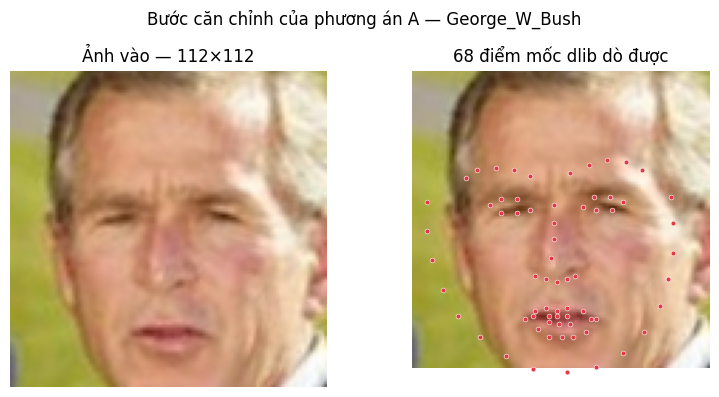

Toạ độ điểm mốc nằm trong khoảng x[5, 98] y[33, 113] trên ảnh 112×112


In [5]:
anh_minh_hoa = [p for p in duong_dan_anh if p.parent.name == "George_W_Bush"][0]

anh_bgr = cv2.imread(str(anh_minh_hoa))
anh_rgb = cv2.cvtColor(anh_bgr, cv2.COLOR_BGR2RGB)
cao, rong = anh_rgb.shape[:2]

bo_do_diem_moc = dlib.shape_predictor(CFG["dlib"]["shape_predictor"])
mo_hinh_dlib = dlib.face_recognition_model_v1(CFG["dlib"]["model_path"])

diem_moc = bo_do_diem_moc(anh_rgb, dlib.rectangle(0, 0, rong, cao))
toa_do = np.array([[p.x, p.y] for p in diem_moc.parts()])

fig, truc = plt.subplots(1, 2, figsize=(8, 4))
truc[0].imshow(anh_rgb)
truc[0].set_title(f"Ảnh vào — {anh_rgb.shape[1]}×{anh_rgb.shape[0]}")
truc[1].imshow(anh_rgb)
truc[1].scatter(toa_do[:, 0], toa_do[:, 1], s=12, c="#e63946", edgecolors="white", linewidths=0.4)
truc[1].set_title(f"{len(toa_do)} điểm mốc dlib dò được")
for t in truc:
    t.axis("off")
fig.suptitle(f"Bước căn chỉnh của phương án A — {anh_minh_hoa.parent.name}")
fig.tight_layout()
plt.show()

print(f"Toạ độ điểm mốc nằm trong khoảng x[{toa_do[:, 0].min()}, {toa_do[:, 0].max()}]", end="")
print(f" y[{toa_do[:, 1].min()}, {toa_do[:, 1].max()}] trên ảnh {rong}×{cao}")

## 6. Vectơ đặc trưng — thứ mà cả hệ thống xoay quanh

Đây là điểm mấu chốt của cách tiếp cận: **không huấn luyện mô hình phân loại từng người**. Mỗi ảnh
được biến thành một vectơ, đăng ký một người là lưu lại vectơ trung bình của họ, nhận diện là so
vectơ mới với các vectơ đã lưu. Thêm người mới không cần huấn luyện lại gì.

In [6]:
v_dlib = bo_dlib.trich_dac_trung(anh_bgr)
v_arcface = bo_arcface.trich_dac_trung(anh_bgr)

for ten, v in (("A · dlib", v_dlib), ("B · ArcFace", v_arcface)):
    print(f"{ten}")
    print(f"  hình dạng   : {v.shape}")
    print(f"  kiểu dữ liệu: {v.dtype}")
    print(f"  độ dài L2   : {float(np.linalg.norm(v)):.6f}")
    print(f"  5 giá trị đầu: {np.array2string(v[:5], precision=4)}")
    print()

A · dlib
  hình dạng   : (128,)
  kiểu dữ liệu: float32
  độ dài L2   : 1.000000
  5 giá trị đầu: [-0.0464  0.107   0.0616 -0.0233 -0.1405]

B · ArcFace
  hình dạng   : (512,)
  kiểu dữ liệu: float32
  độ dài L2   : 1.000000
  5 giá trị đầu: [-0.0768  0.0249 -0.024  -0.0281  0.0331]



Độ dài L2 bằng đúng 1 ở cả hai. Đây không phải trùng hợp: cả hai backend chuẩn hoá L2 trước khi trả
về, vì độ dài vectơ **không mang thông tin về danh tính** — nó phản ánh độ tương phản, độ sáng, chất
lượng ảnh. Không chuẩn hoá thì khi lấy trung bình lúc đăng ký, một ảnh sáng rõ sẽ lấn át phần còn lại.

Vì mọi vectơ nằm trên mặt cầu đơn vị, độ tương đồng cosin rút gọn thành phép nhân vô hướng — điều
này được dùng ở mục 8 để tính toàn bộ ma trận trong một phép nhân ma trận duy nhất.

## 7. Một chế độ hỏng im lặng — thứ tự kênh màu

OpenCV đọc ảnh ra thứ tự kênh **BGR**; dlib chờ **RGB**. Quên đổi thì chuyện gì xảy ra?

Không có ngoại lệ nào được ném. Mô hình vẫn trả về đủ 128 số. Ô dưới đo xem hai vectơ — một từ ảnh
RGB đúng, một từ ảnh BGR sai — lệch nhau bao nhiêu.

In [7]:
# Đường đi ĐÚNG: đổi BGR sang RGB trước khi đưa vào dlib.
vec_dung = np.asarray(mo_hinh_dlib.compute_face_descriptor(anh_rgb, diem_moc, 0), dtype=np.float32)

# Đường đi SAI: đưa thẳng ảnh BGR. Không lỗi, không cảnh báo.
diem_moc_bgr = bo_do_diem_moc(anh_bgr, dlib.rectangle(0, 0, rong, cao))
vec_sai = np.asarray(
    mo_hinh_dlib.compute_face_descriptor(anh_bgr, diem_moc_bgr, 0), dtype=np.float32
)

print(f"Vectơ từ đường đi sai vẫn có {vec_sai.shape[0]} chiều, không ngoại lệ nào được ném.")
print(f"Độ tương đồng giữa hai vectơ : {do_tuong_dong(vec_dung, vec_sai):.4f}")
print(f"Sai lệch lớn nhất theo chiều : {float(np.abs(vec_dung - vec_sai).max()):.4f}")

Vectơ từ đường đi sai vẫn có 128 chiều, không ngoại lệ nào được ném.
Độ tương đồng giữa hai vectơ : 0.9944
Sai lệch lớn nhất theo chiều : 0.0308


Con số này giải thích vì sao lỗi loại đó khó bắt: hai vectơ **giống nhau tới hơn 99 %**. Đủ giống để
mọi phép kiểm dựa trên ngưỡng tương đồng thông thường đều bỏ qua, nhưng vẫn đủ khác để làm xói mòn
độ chính xác khi phải phân biệt hàng trăm danh tính.

Đề tài đã vấp đúng chế độ hỏng này hai lần:

1. **Phương án B** — dùng ảnh thô không chuẩn hoá thì mọi khuôn mặt cho độ tương đồng 0,87–0,91 với
   nhau. Hệ thống trông vẫn chạy mà thực chất không phân biệt được ai với ai. Phát hiện bằng thực
   nghiệm ngày 22/08/2026, ghi ở `models/README.md` §3.3.
2. **Phương án A** — vòng review thứ nhất của `P3-02` phát hiện phép kiểm canh bước đổi kênh màu
   thật ra không canh được gì, vì nó dựa trên ngưỡng 0,99 trong khi khoảng cách thật chỉ là 0,9955.
   Sửa bằng cách so khớp gần-đúng-tuyệt-đối với một mốc tham chiếu dựng độc lập.

Bài học chung: **một mô-đun chạy không lỗi không có nghĩa là nó chạy đúng.** Với mô hình học sâu,
cách hỏng phổ biến nhất không phải là đổ vỡ mà là im lặng xuống cấp.

## 8. Trích đặc trưng toàn bộ tập dữ liệu

Chạy cả hai backend trên toàn bộ ảnh để có dữ liệu cho hai mục cuối.

In [8]:
logging.getLogger().setLevel(logging.WARNING)  # tắt bớt log để đầu ra gọn

anh_tat_ca = [cv2.imread(str(p)) for p in duong_dan_anh]
assert all(a is not None for a in anh_tat_ca), "Có ảnh không đọc được"

V = {
    "A · dlib": np.stack([bo_dlib.trich_dac_trung(a) for a in anh_tat_ca]),
    "B · ArcFace": np.stack([bo_arcface.trich_dac_trung(a) for a in anh_tat_ca]),
}

for ten, m in V.items():
    print(f"{ten:12s} ma trận đặc trưng {m.shape}  (số ảnh, số chiều)")

A · dlib     ma trận đặc trưng (200, 128)  (số ảnh, số chiều)
B · ArcFace  ma trận đặc trưng (200, 512)  (số ảnh, số chiều)


## 9. Ma trận độ tương đồng

Lấy hai danh tính nhiều ảnh nhất và so mọi ảnh với mọi ảnh. Nếu khối nhận diện làm đúng việc, ta
phải thấy hai khối vuông sáng trên đường chéo (cùng người) và vùng tối ở hai góc (khác người).

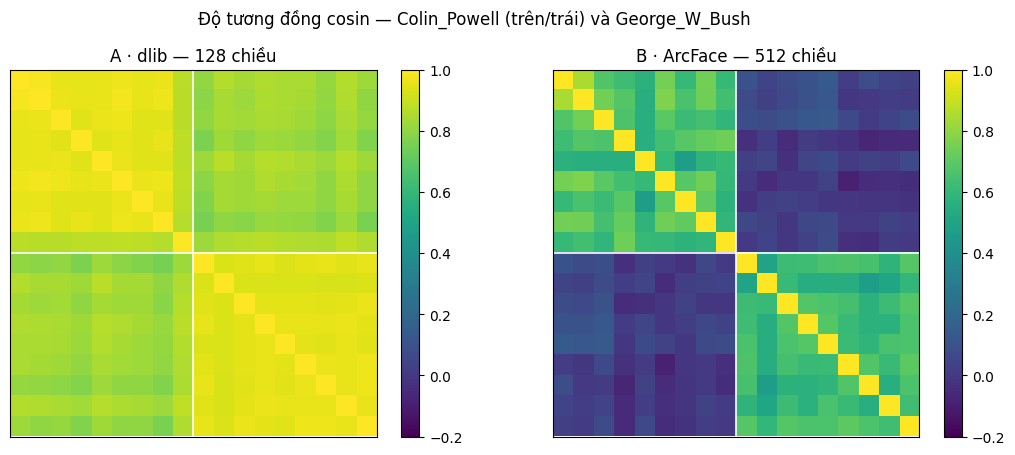

In [9]:
hai_nguoi = danh_tinh[np.argsort(-so_anh_moi_nguoi)[:2]]
chi_so = np.concatenate([np.where(nhan == ten)[0] for ten in hai_nguoi])
ranh_gioi = int((nhan[chi_so] == hai_nguoi[0]).sum())

fig, truc = plt.subplots(1, 2, figsize=(11, 4.6))
for t, (ten, m) in zip(truc, V.items()):
    S = m[chi_so] @ m[chi_so].T
    anh_ve = t.imshow(S, cmap="viridis", vmin=-0.2, vmax=1.0)
    t.axhline(ranh_gioi - 0.5, color="white", linewidth=1.2)
    t.axvline(ranh_gioi - 0.5, color="white", linewidth=1.2)
    t.set_title(f"{ten} — {m.shape[1]} chiều")
    t.set_xticks([])
    t.set_yticks([])
    fig.colorbar(anh_ve, ax=t, fraction=0.046)

fig.suptitle(f"Độ tương đồng cosin — {hai_nguoi[0]} (trên/trái) và {hai_nguoi[1]}")
fig.tight_layout()
plt.show()

## 10. Phân bố cùng người và khác người

Ma trận ở trên chỉ nhìn được hai danh tính. Mục này tính **toàn bộ** các cặp ảnh trong tập dữ liệu
rồi tách làm hai nhóm: cặp cùng danh tính và cặp khác danh tính.

Đây là hình dạng gốc của bài toán nhận diện: chọn một ngưỡng cắt giữa hai phân bố. Phần chồng lấn
chính là chỗ sinh ra lỗi — người lạ bị nhận nhầm (FAR) và chủ nhà bị từ chối (FRR).

Chỉ số **d′** đo khoảng cách giữa hai phân bố tính theo đơn vị độ lệch chuẩn. Nó cho phép so sánh hai
phương án mà không cần chọn ngưỡng trước — d′ càng lớn thì hai nhóm càng tách rời, và ngưỡng nào
cũng dễ chọn hơn.

Tổng số cặp ảnh    : 19,900
  cặp cùng người   : 115
  cặp khác người   : 19,785



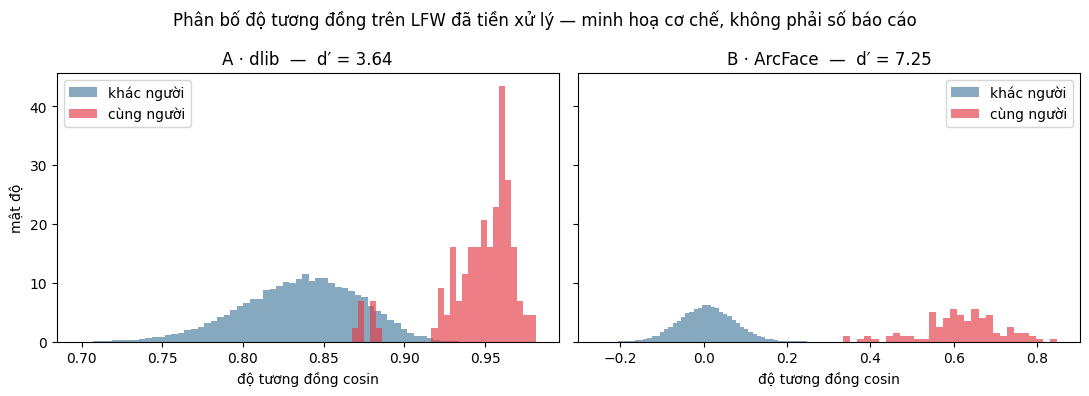

                          cùng người            khác người      d′
A · dlib             0.9468 ± 0.0235       0.8353 ± 0.0364    3.64
B · ArcFace          0.6160 ± 0.0980       0.0084 ± 0.0668    7.25


In [10]:
tren, duoi = np.triu_indices(len(nhan), k=1)
cung_nguoi = nhan[tren] == nhan[duoi]

print(f"Tổng số cặp ảnh    : {len(tren):,}")
print(f"  cặp cùng người   : {int(cung_nguoi.sum()):,}")
print(f"  cặp khác người   : {int((~cung_nguoi).sum()):,}")
print()

fig, truc = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
tom_tat = {}

for t, (ten, m) in zip(truc, V.items()):
    diem = (m[tren] * m[duoi]).sum(axis=1)
    a, b = diem[cung_nguoi], diem[~cung_nguoi]
    d_prime = (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)
    tom_tat[ten] = (a, b, d_prime)

    t.hist(b, bins=60, density=True, alpha=0.65, label="khác người", color="#457b9d")
    t.hist(a, bins=30, density=True, alpha=0.65, label="cùng người", color="#e63946")
    t.set_title(f"{ten}  —  d′ = {d_prime:.2f}")
    t.set_xlabel("độ tương đồng cosin")
    t.legend()

truc[0].set_ylabel("mật độ")
fig.suptitle("Phân bố độ tương đồng trên LFW đã tiền xử lý — minh hoạ cơ chế, không phải số báo cáo")
fig.tight_layout()
plt.show()

print(f"{'':14s}{'cùng người':>22s}{'khác người':>22s}{'d′':>8s}")
for ten, (a, b, d_prime) in tom_tat.items():
    print(
        f"{ten:14s}"
        f"{a.mean():>13.4f} ± {a.std():.4f}"
        f"{b.mean():>13.4f} ± {b.std():.4f}"
        f"{d_prime:>8.2f}"
    )

## 11. Đọc kết quả

Cả hai phương án đều tách được hai phân bố, tức khối nhận diện hoạt động đúng nguyên lý. Con số d′
cho biết phương án nào tách rõ hơn **trên tập dữ liệu này**.

### Bốn lý do không được dùng kết quả trên để chọn phương án

**Sai miền dữ liệu.** LFW là ảnh thu từ web, khác điều kiện camera của hệ thống về độ nét, ánh sáng,
kích thước khuôn mặt. Đó chính là lý do đề tài phải có bước domain adaptation và ba nguồn impostor
riêng biệt.

**Sai bài toán.** Ở đây là so từng cặp ảnh. Hệ thống thật so một ảnh với **vectơ trung bình** của
người đã đăng ký, dựng từ ít nhất 10 ảnh. Vectơ trung bình ổn định hơn từng ảnh lẻ.

**Thiếu chỉ số quyết định.** Chọn phương án phải dựa trên FAR đo ở ngưỡng đã chốt, cùng với FPS và
độ trễ trên phần cứng đích. d′ chỉ là chỉ báo sơ bộ.

**Sai phần cứng.** Phương án A và B có thể đảo thứ tự khi chuyển từ máy phát triển x86-64 sang
Raspberry Pi 5. Số chiều 512 so với 128 và hai runtime khác nhau đều ảnh hưởng tới tốc độ, và tốc độ
là một trong năm chỉ tiêu cam kết.

### Việc còn lại của Phase 3

| Bước | Nội dung | Trạng thái |
|---|---|---|
| 3.1 · 3.3 | Interface chung và phương án B | ✅ `P3-01` |
| 3.2 | Phương án A | ✅ `P3-02` |
| 3.4 | `scripts/enroll.py` — sinh vectơ đại diện | chưa làm |
| 3.5 | Quét ngưỡng, vẽ ROC/DET | chờ 3.4 |
| 3.6 · 3.7 | Đo trên phần cứng đích, ba con số FAR | chờ Raspberry Pi 5 và camera |
| 3.7b · 3.7c | Kiểm chứng domain adaptation, chốt ngưỡng | chờ 3.7 |
| 3.8 · 3.9 | Bảng so sánh và kết luận chọn phương án | chờ 3.7c |